# CNN ile Görüntü Sınıflandırma
**Kutay Kalay** · SoftITo Yapay Zeka · 25.09.2026

Keras ile evrişimli sinir ağı (CNN) kurup **Fashion-MNIST** veri setindeki kıyafet görüntülerini 10 sınıfa ayırıyoruz.
Ayarlar hücresindeki `VERI_SETI` değişkeni değiştirilerek aynı kod MNIST ya da CIFAR-10 ile de çalıştırılabilir.

> Colab'da **Çalışma zamanı → Çalışma zamanı türünü değiştir → GPU** seçilirse eğitim çok daha hızlı olur.

## 1. Ayarlar
Bütün ayarlar tek yerde duruyor. Deneme yaparken sadece bu hücreyi değiştirmek yetiyor.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 7
VERI_SETI = "fashion_mnist"      # "mnist", "fashion_mnist" veya "cifar10"
BATCH = 128
EPOCH = 40
OGRENME_HIZI = 1e-3
DOGRULAMA_ORANI = 0.15
CIKTI = "sonuclar"

os.makedirs(CIKTI, exist_ok=True)
keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
SINIFLAR = {
    "mnist": [str(i) for i in range(10)],
    "fashion_mnist": ["tişört", "pantolon", "kazak", "elbise", "mont",
                      "sandalet", "gömlek", "spor ayakkabı", "çanta", "bot"],
    "cifar10": ["uçak", "otomobil", "kuş", "kedi", "geyik",
                "köpek", "kurbağa", "at", "gemi", "kamyon"],
}

## 2. Veriyi yükleme ve tanıma
Görüntüler `(adet, yükseklik, genişlik, kanal)` şeklinde olmalı.
MNIST ve Fashion-MNIST gri tonlu olduğu için kanal boyutu yok. `np.newaxis` ile sona 1 kanal ekliyoruz.

In [3]:
yukleyiciler = {
    "mnist": keras.datasets.mnist,
    "fashion_mnist": keras.datasets.fashion_mnist,
    "cifar10": keras.datasets.cifar10,
}
(x_tum, y_tum), (x_test, y_test) = yukleyiciler[VERI_SETI].load_data()
y_tum, y_test = y_tum.ravel(), y_test.ravel()

if x_tum.ndim == 3:
    x_tum, x_test = x_tum[..., np.newaxis], x_test[..., np.newaxis]

sinif_adlari = SINIFLAR[VERI_SETI]
print("Eğitim:", x_tum.shape, "| Test:", x_test.shape)
print("Piksel aralığı:", x_tum.min(), "-", x_tum.max(), "| tip:", x_tum.dtype)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Eğitim: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)
Piksel aralığı: 0 - 255 | tip: uint8


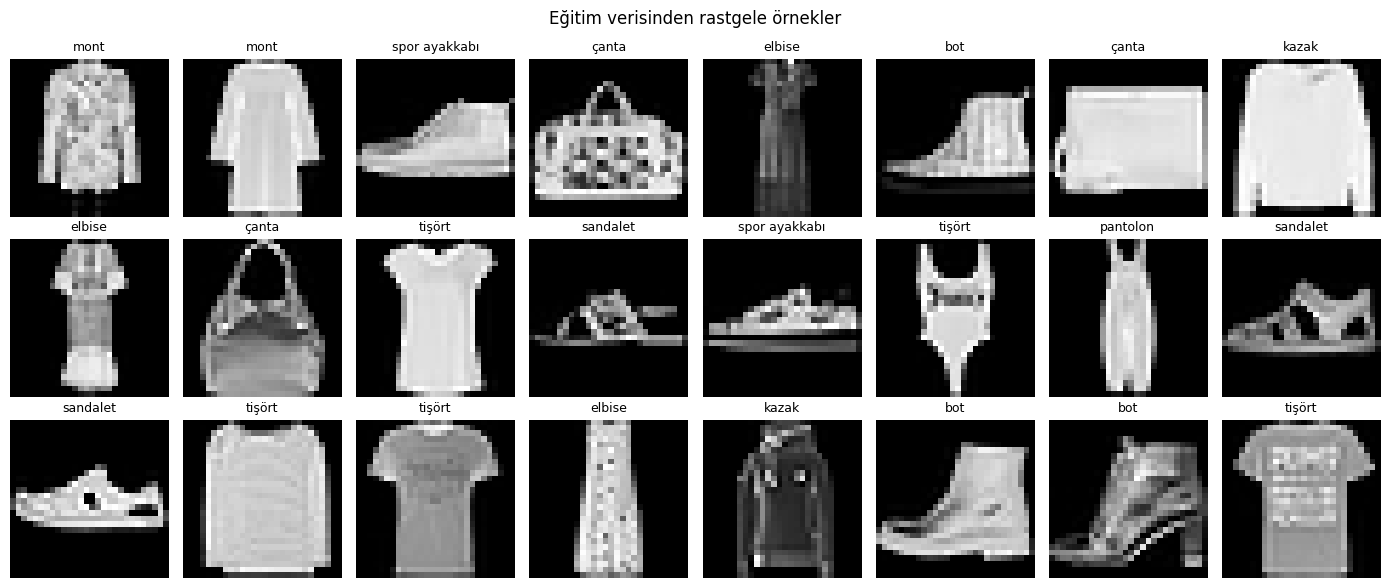

In [4]:
def goster(resim, ax, baslik=""):
    ax.imshow(resim.squeeze(), cmap="gray" if resim.shape[-1] == 1 else None)
    ax.set_title(baslik, fontsize=9)
    ax.axis("off")

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for ax, i in zip(axes.ravel(), np.random.choice(len(x_tum), 24, replace=False)):
    goster(x_tum[i], ax, sinif_adlari[y_tum[i]])
plt.suptitle("Eğitim verisinden rastgele örnekler")
plt.tight_layout()
plt.show()

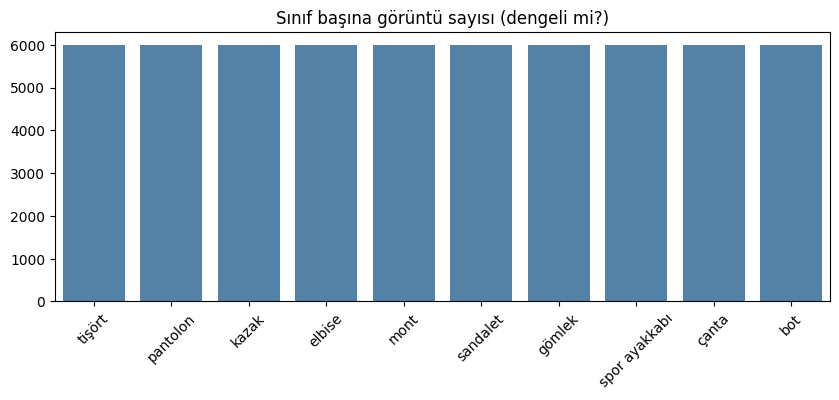

In [5]:
sayilar = np.bincount(y_tum, minlength=len(sinif_adlari))
plt.figure(figsize=(10, 3.5))
sns.barplot(x=sinif_adlari, y=sayilar, color="steelblue")
plt.xticks(rotation=45)
plt.title("Sınıf başına görüntü sayısı (dengeli mi?)")
plt.show()

## 3. Train / validation ayrımı ve `tf.data` akışı
- Eğitim verisinin %15'ini **validation** için ayırıyoruz (`stratify` ile sınıf oranları korunuyor).
- `tf.data` veriyi batch'lere böler. `prefetch` sayesinde GPU bir batch'i işlerken bir sonraki batch hazırlanır.
- Sadece eğitim verisini karıştırıyoruz.

In [6]:
x_egitim, x_dogr, y_egitim, y_dogr = train_test_split(
    x_tum, y_tum, test_size=DOGRULAMA_ORANI, stratify=y_tum, random_state=SEED)

def veri_akisi(x, y, karistir):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if karistir:
        ds = ds.shuffle(len(x), seed=SEED)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

egitim_ds = veri_akisi(x_egitim, y_egitim, karistir=True)
dogr_ds = veri_akisi(x_dogr, y_dogr, karistir=False)
test_ds = veri_akisi(x_test, y_test, karistir=False)
print(f"train: {len(x_egitim)} | validation: {len(x_dogr)} | test: {len(x_test)}")

train: 51000 | validation: 9000 | test: 10000


## 4. Veri artırma (data augmentation)
Eğitim sırasında her görüntüyü rastgele biraz kaydırıp yakınlaştırıyoruz, gerekiyorsa aynalıyoruz.
Model böylece aynı görüntüyü her epoch'ta biraz farklı görür ve **ezberlemesi zorlaşır**.
Bu katmanlar sadece eğitimde çalışır. Tahmin sırasında otomatik olarak kapanır.

MNIST'te yatay aynalama kullanılmaz, çünkü aynalanmış bir "2" artık "2" değildir.

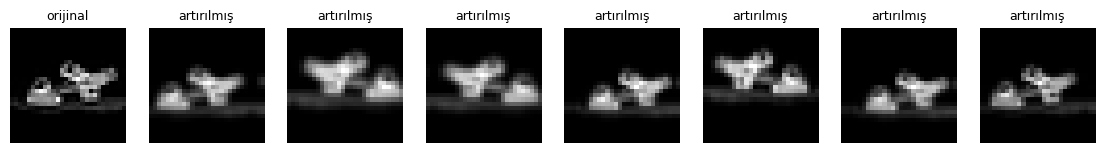

In [7]:
artirma_katmanlari = [layers.RandomTranslation(0.1, 0.1, seed=SEED), layers.RandomZoom(0.1, seed=SEED)]
if VERI_SETI != "mnist":
    artirma_katmanlari.insert(0, layers.RandomFlip("horizontal", seed=SEED))
veri_artirma = keras.Sequential(artirma_katmanlari, name="veri_artirma")

ornek = x_egitim[:1].astype("float32")
fig, axes = plt.subplots(1, 8, figsize=(14, 2.2))
goster(ornek[0], axes[0], "orijinal")
for ax in axes[1:]:
    goster(veri_artirma(ornek, training=True)[0].numpy(), ax, "artırılmış")
plt.show()

## 5. Modeli kurma
Katmanların görevleri:

| Katman | Ne yapar? |
|---|---|
| `Rescaling(1/255)` | Pikselleri 0–255 aralığından 0–1 aralığına çeker |
| `Conv2D` | 3×3'lük filtrelerle kenar, doku, desen gibi yerel özellikleri çıkarır |
| `BatchNormalization` | Katman çıktısını normalize eder, eğitimi hızlandırır ve kararlı hale getirir |
| `MaxPooling2D` | Görüntüyü yarıya küçültür (2×2 bölgenin en büyüğünü alır) |
| `Dropout` | Nöronların bir kısmını rastgele kapatır, overfit'i azaltır |
| `GlobalAveragePooling2D` | Her filtre haritasının ortalamasını alıp tek bir vektöre indirir |
| `Dense(softmax)` | 10 sınıf için toplamı 1 olan olasılıklar üretir |

Aynı yapıda üç blok kullanıyoruz ve her blokta filtre sayısı ikiye katlanıyor (32 → 64 → 128).
Görüntü küçüldükçe daha soyut özellikler öğreniliyor.

In [8]:
def evrisim_blogu(x, filtre, dropout):
    for _ in range(2):
        x = layers.Conv2D(filtre, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    return layers.Dropout(dropout)(x)


def model_kur(girdi_sekli, sinif_sayisi):
    girdi = keras.Input(shape=girdi_sekli)
    x = veri_artirma(girdi)
    x = layers.Rescaling(1 / 255)(x)
    x = evrisim_blogu(x, 32, 0.2)
    x = evrisim_blogu(x, 64, 0.3)
    x = evrisim_blogu(x, 128, 0.4)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    cikti = layers.Dense(sinif_sayisi, activation="softmax")(x)
    return keras.Model(girdi, cikti, name="cnn")


model = model_kur(x_egitim.shape[1:], len(sinif_adlari))
model.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ veri_artirma (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,578 (1.17 MB)

 Trainable params: 304,682 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

## 6. Derleme ve eğitim
- **Loss:** `SparseCategoricalCrossentropy`. Çok sınıflı problemlerde etiketler 0, 1, 2… gibi tam sayı olduğunda kullanılır. Etiketleri one-hot'a çevirmeye gerek kalmaz.
- **Callback'ler:**
  - `EarlyStopping`: Validation loss 6 epoch boyunca iyileşmezse eğitimi durdurur ve en iyi ağırlıklara döner.
  - `ReduceLROnPlateau`: İlerleme yavaşlayınca öğrenme hızını yarıya indirir.
  - `ModelCheckpoint`: En iyi modeli diske kaydeder.

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(OGRENME_HIZI),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

callbackler = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    keras.callbacks.ModelCheckpoint(os.path.join(CIKTI, "en_iyi_model.keras"),
                                    monitor="val_accuracy", save_best_only=True),
]

gecmis = model.fit(egitim_ds, validation_data=dogr_ds, epochs=EPOCH, callbacks=callbackler, verbose=2)

Epoch 1/40
399/399 - 18s - 46ms/step - accuracy: 0.6987 - loss: 0.8158 - val_accuracy: 0.1879 - val_loss: 3.5125 - learning_rate: 0.0010
Epoch 2/40
399/399 - 10s - 25ms/step - accuracy: 0.8057 - loss: 0.5218 - val_accuracy: 0.8039 - val_loss: 0.5705 - learning_rate: 0.0010
Epoch 3/40
399/399 - 11s - 28ms/step - accuracy: 0.8317 - loss: 0.4538 - val_accuracy: 0.8343 - val_loss: 0.4467 - learning_rate: 0.0010
Epoch 4/40
399/399 - 19s - 49ms/step - accuracy: 0.8498 - loss: 0.4060 - val_accuracy: 0.8703 - val_loss: 0.3543 - learning_rate: 0.0010
Epoch 5/40
399/399 - 10s - 24ms/step - accuracy: 0.8606 - loss: 0.3825 - val_accuracy: 0.8694 - val_loss: 0.3527 - learning_rate: 0.0010
Epoch 6/40
399/399 - 10s - 25ms/step - accuracy: 0.8673 - loss: 0.3635 - val_accuracy: 0.8919 - val_loss: 0.2948 - learning_rate: 0.0010
Epoch 7/40
399/399 - 10s - 25ms/step - accuracy: 0.8744 - loss: 0.3455 - val_accuracy: 0.8909 - val_loss: 0.3049 - learning_rate: 0.0010
Epoch 8/40
399/399 - 11s - 27ms/step - ac

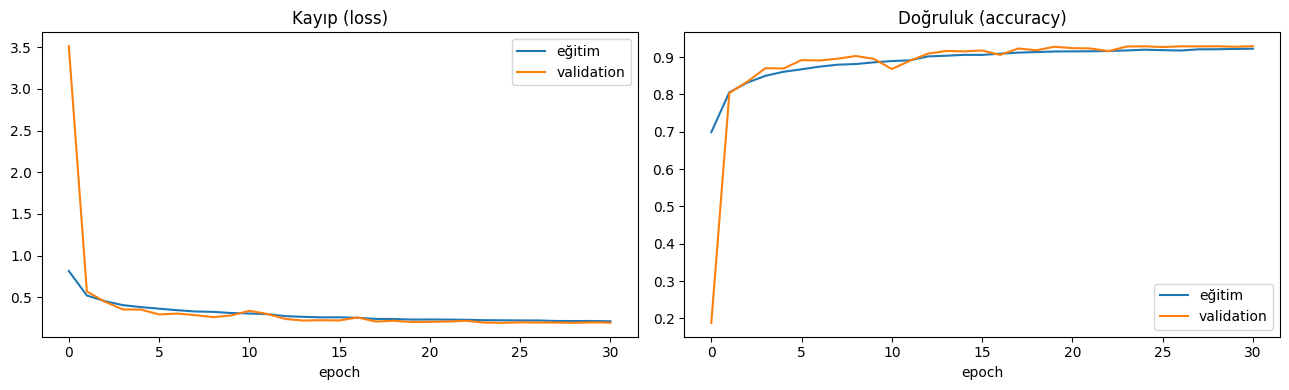

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metrik, baslik in zip(axes, ["loss", "accuracy"], ["Kayıp (loss)", "Doğruluk (accuracy)"]):
    ax.plot(gecmis.history[metrik], label="eğitim")
    ax.plot(gecmis.history[f"val_{metrik}"], label="validation")
    ax.set(title=baslik, xlabel="epoch")
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CIKTI, "egitim_egrileri.png"), dpi=200)
plt.show()

## 7. Test verisinde değerlendirme
`predict`, her görüntü için 10 olasılık döndürür. `argmax` ile en yüksek olasılıklı sınıfı seçiyoruz.

In [11]:
test_kayip, test_dogruluk = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_kayip:.4f} | Test accuracy: {test_dogruluk:.4f}")

olasiliklar = model.predict(test_ds, verbose=0)
y_tahmin = olasiliklar.argmax(axis=1)

print(classification_report(y_test, y_tahmin, target_names=sinif_adlari, digits=3))

Test loss: 0.2027 | Test accuracy: 0.9266
               precision    recall  f1-score   support

       tişört      0.868     0.877     0.873      1000
     pantolon      0.993     0.984     0.988      1000
        kazak      0.901     0.900     0.900      1000
       elbise      0.926     0.916     0.921      1000
         mont      0.889     0.913     0.901      1000
     sandalet      0.985     0.986     0.986      1000
       gömlek      0.783     0.768     0.775      1000
spor ayakkabı      0.957     0.973     0.965      1000
        çanta      0.988     0.987     0.987      1000
          bot      0.976     0.962     0.969      1000

     accuracy                          0.927     10000
    macro avg      0.927     0.927     0.927     10000
 weighted avg      0.927     0.927     0.927     10000



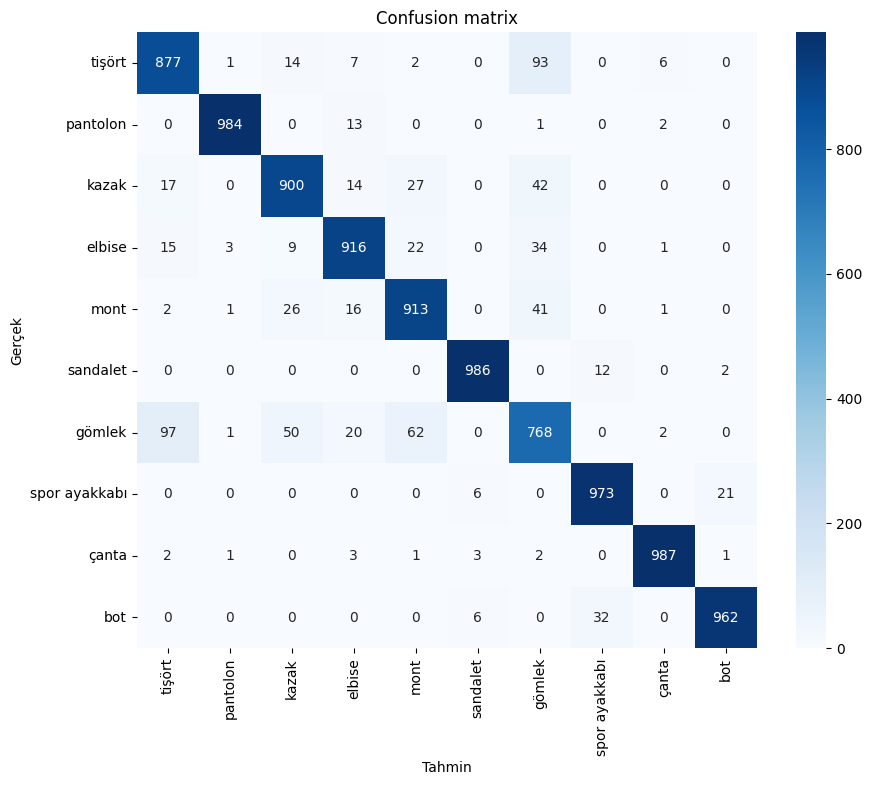

In [12]:
cm = confusion_matrix(y_test, y_tahmin)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=sinif_adlari, yticklabels=sinif_adlari)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion matrix")
plt.savefig(os.path.join(CIKTI, "confusion_matrix.png"), dpi=200)
plt.show()

### En çok karıştırılan sınıf çiftleri
Confusion matrix'in köşegeni doğru tahminlerdir. Köşegen dışındaki en büyük değerler, modelin en çok karıştırdığı sınıf çiftlerini gösterir.

In [13]:
hatalar = cm.copy()
np.fill_diagonal(hatalar, 0)
en_cok = np.dstack(np.unravel_index(np.argsort(hatalar.ravel())[::-1][:5], hatalar.shape))[0]
for gercek, tahmin in en_cok:
    print(f"{sinif_adlari[gercek]:>14s} → {sinif_adlari[tahmin]:<14s} {hatalar[gercek, tahmin]} kez")

        gömlek → tişört         97 kez
        tişört → gömlek         93 kez
        gömlek → mont           62 kez
        gömlek → kazak          50 kez
         kazak → gömlek         42 kez


Toplam 734 yanlış tahmin (7.3%)


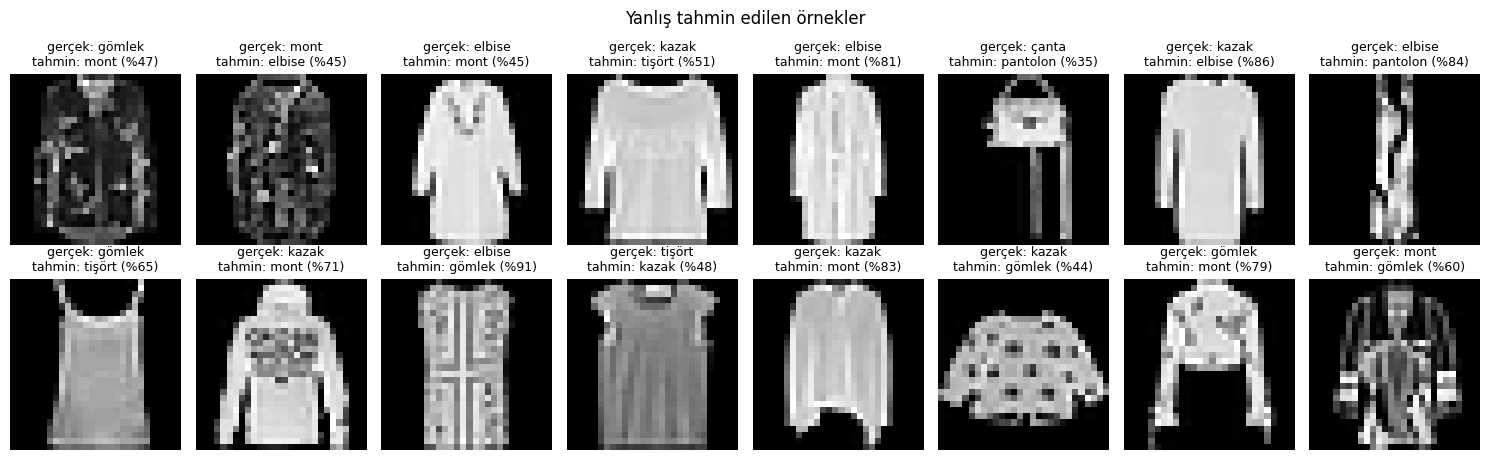

In [14]:
yanlislar = np.where(y_tahmin != y_test)[0]
print(f"Toplam {len(yanlislar)} yanlış tahmin ({len(yanlislar) / len(y_test):.1%})")

fig, axes = plt.subplots(2, 8, figsize=(15, 4.8))
for ax, i in zip(axes.ravel(), np.random.choice(yanlislar, 16, replace=False)):
    goster(x_test[i], ax, f"gerçek: {sinif_adlari[y_test[i]]}\ntahmin: {sinif_adlari[y_tahmin[i]]} "
                          f"(%{olasiliklar[i].max() * 100:.0f})")
plt.suptitle("Yanlış tahmin edilen örnekler")
plt.tight_layout()
plt.show()

## 8. Modeli kaydetme ve tekrar yükleme
Kaydedilen model, yeniden eğitmeye gerek kalmadan başka bir notebook'ta yüklenip kullanılabilir.
Colab'daki dosyalar oturum kapanınca silinir. Saklamak için sol paneldeki **Dosyalar** sekmesinden `sonuclar` klasörünü indirmek gerekir.

In [15]:
yol = os.path.join(CIKTI, "cnn_model.keras")
model.save(yol)

yuklenen = keras.models.load_model(yol)
ayni_mi = np.allclose(yuklenen.predict(x_test[:32], verbose=0), model.predict(x_test[:32], verbose=0), atol=1e-5)
print("Kaydedilen dosya:", yol, "| Yüklenen model aynı tahminleri veriyor mu?", ayni_mi)
print("Klasördeki dosyalar:", os.listdir(CIKTI))

Kaydedilen dosya: sonuclar/cnn_model.keras | Yüklenen model aynı tahminleri veriyor mu? True
Klasördeki dosyalar: ['confusion_matrix.png', 'egitim_egrileri.png', 'en_iyi_model.keras', 'cnn_model.keras']
